In [1]:
from utils import *

In [2]:
dt_file = ReadDTFile("data/V09372A_drift_time_map.dat")

In [16]:
def read_mpp_file(file):

    n_waveforms_pass = 0
    n_waveforms = 0
    n_evts = 0

    data_dict = {
        f'{i}': [] for i in ['x', 'y', 'z', 'r', 't', 'dts', 'E', 'Esum', 'ievt_n']
    }

    tree = uproot.open(f"{file}:simTree")
    df = tree.arrays(
        [
            'cluster_positionX', 'cluster_positionY', 'cluster_positionZ',
            'cluster_energy', 'mage_id', 'ievt', 'drift_times_vector'
        ], library='ak'
    )
    df['ievt_n'] = df['ievt'] + int(n_evts)

    df_sel = df[ak.any(df['mage_id'] == 1, axis=-1)]
    for i_df_sel in tqdm(df_sel):
        mage_id = i_df_sel.mage_id
        ievt_n = i_df_sel.ievt_n

        for index, mage_id_ in enumerate(mage_id):
            if mage_id_ == 1:
                cx = i_df_sel.cluster_positionX[index]
                cy = i_df_sel.cluster_positionY[index]
                cz = i_df_sel.cluster_positionZ[index]
                ce = i_df_sel.cluster_energy[index]*1000
                sum_ce = sum(ce)
                n_waveforms += 1

                if sum_ce > 500: 
                    n_waveforms_pass += 1
                    for cx_, cy_, cz_, ce_ in zip(cx, cy, cz, ce):
                        cz_ = cz_ + GED_HEIGHT/2
                        cr_ = np.sqrt(cx_**2 + cy_**2)
                        dt_ = dt_file.GetTime(cr_, cz_)
                
                        data_dict['E'].append(ce_),
                        data_dict['r'].append(cr_),
                        data_dict['z'].append(cz_),
                        data_dict['y'].append(cy_),
                        data_dict['x'].append(cx_),
                        data_dict['t'].append(1.4E7)
                        data_dict['dts'].append(dt_),
                        data_dict['Esum'].append(sum_ce)
                        data_dict['ievt_n'].append(ievt_n)
                        # append_PET_file(args.pet_file, data_dict)

    df_data = pd.DataFrame(data_dict)
    df_data = df_data.explode(['x', 'y', 'z', 'r', 'E', 'dts', 'Esum', 'ievt_n']).reset_index().drop(columns=['index'])
    print(n_waveforms, n_waveforms_pass)

    return df_data

In [17]:
df_data_after  = read_mpp_file("/Users/williamquinn/Desktop/V09372A-33025622_mpp_new.root")
df_data_before = read_mpp_file("/Users/williamquinn/Desktop/V09372A-32308680_mpp_old.root")

100%|██████████| 35420/35420 [00:21<00:00, 1630.42it/s]


35420 18831


100%|██████████| 99877/99877 [01:04<00:00, 1553.46it/s]


99877 58687


Text(0, 0.5, 'Counts /(10 keV)')

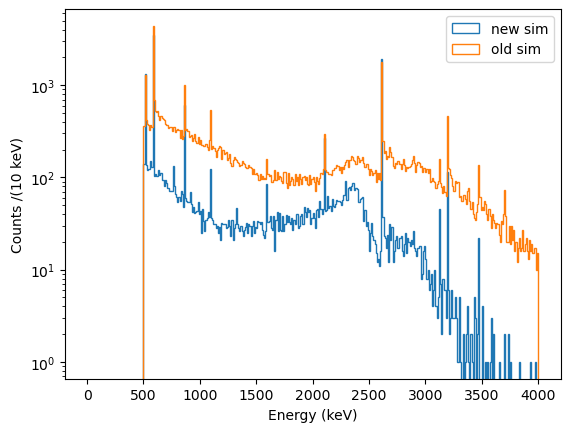

In [20]:
plt.figure()

_ = plt.hist(
    df_data_after.groupby('ievt_n').Esum.mean(),
    range=(0,4000), bins=400, histtype='step', label='new sim'
)
_ = plt.hist(
    df_data_before.groupby('ievt_n').Esum.mean(),
    range=(0,4000), bins=400, histtype='step', label='old sim'
)
plt.yscale('log')
plt.legend()

plt.xlabel('Energy (keV)')
plt.ylabel('Counts /(10 keV)')